In [10]:
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
from sklearn.metrics import (accuracy_score, precision_score, 
                              recall_score, f1_score, confusion_matrix,
                              ConfusionMatrixDisplay)
from sklearn.model_selection import train_test_split

In [11]:
df = pd.read_csv('../data/processed/features_final.csv')

features = [
    'hour_of_day',
    'day_of_week_num',
    'is_break_period',
    'is_after_hours',
    'occupancy',
    'fan_status',
    'light_status',
    'power_consumption_w',
    'rolling_avg_30min',
    'lag_1h_power'
]

X = df[features]
y = df['wastage_label']

_, X_test, _, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

with open('../models/random_forest_model.pkl', 'rb') as f:
    rf = pickle.load(f)

In [12]:
y_pred = rf.predict(X_test)

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1-Score :", f1_score(y_test, y_pred))

Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1-Score : 1.0


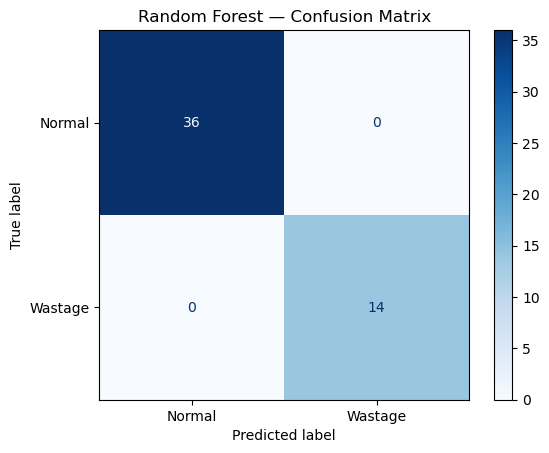

In [13]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal', 'Wastage'])
disp.plot(cmap='Blues')
plt.title("Random Forest — Confusion Matrix")
plt.savefig('../docs/confusion_matrix.png')
plt.show()

In [17]:
import pickle

# Load scaler
with open('../models/lstm_scaler.pkl', 'rb') as f:
    scaler = pickle.load(f)

# Scale data the same way
data_scaled = scaler.transform(df[features + [target_col]].values)

X_lstm, y_lstm = [], []
for i in range(sequence_length, len(data_scaled)):
    X_lstm.append(data_scaled[i-sequence_length:i, :-1])
    y_lstm.append(data_scaled[i, -1])

X_lstm = np.array(X_lstm)
y_lstm = np.array(y_lstm)

n = len(X_lstm)
val_end = int(n * 0.85)
X_te = X_lstm[val_end:]
y_te_scaled = y_lstm[val_end:]

lstm = load_model('../models/lstm_model.keras')
y_pred_scaled = lstm.predict(X_te).flatten()

# Reverse the scaling to get real watt values
dummy = np.zeros((len(y_te_scaled), len(features) + 1))
dummy[:, -1] = y_te_scaled
y_te = scaler.inverse_transform(dummy)[:, -1]

dummy2 = np.zeros((len(y_pred_scaled), len(features) + 1))
dummy2[:, -1] = y_pred_scaled
y_pred_lstm = scaler.inverse_transform(dummy2)[:, -1]

mae  = mean_absolute_error(y_te, y_pred_lstm)
rmse = np.sqrt(np.mean((y_te - y_pred_lstm)**2))
print(f"MAE:  {mae:.2f} W")
print(f"RMSE: {rmse:.2f} W")

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 387ms/step
MAE:  209.58 W
RMSE: 249.28 W


2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 441ms/step
MAE:  387.77 W
RMSE: 459.47 W


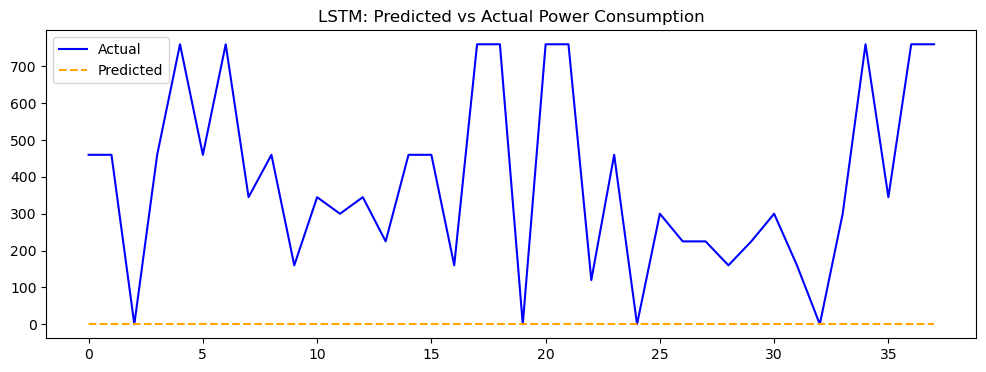

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model
from sklearn.metrics import mean_absolute_error

# --- Step 1: Load data ---
df = pd.read_csv('../data/processed/features_final.csv')

features = [
    'hour_of_day',
    'day_of_week_num',
    'is_break_period',
    'is_after_hours',
    'occupancy',
    'fan_status',
    'light_status',
    'power_consumption_w',
    'rolling_avg_30min',
    'lag_1h_power'
]
target_col = 'power_consumption_w'

# --- Step 2: Re-prepare sequences ---
sequence_length = 3
data = df[features + [target_col]].values

X_lstm, y_lstm = [], []
for i in range(sequence_length, len(data)):
    X_lstm.append(data[i-sequence_length:i, :-1])
    y_lstm.append(data[i, -1])

X_lstm = np.array(X_lstm)
y_lstm = np.array(y_lstm)

# --- Step 3: Split ---
n = len(X_lstm)
train_end = int(n * 0.70)
val_end   = int(n * 0.85)
X_te = X_lstm[val_end:]
y_te = y_lstm[val_end:]

# --- Step 4: Load model and predict ---
lstm = load_model('../models/lstm_model.keras')
y_pred_lstm = lstm.predict(X_te).flatten()

# --- Step 5: Metrics ---
mae  = mean_absolute_error(y_te, y_pred_lstm)
rmse = np.sqrt(np.mean((y_te - y_pred_lstm)**2))
print(f"MAE:  {mae:.2f} W")
print(f"RMSE: {rmse:.2f} W")

# --- Step 6: Plot ---
plt.figure(figsize=(12,4))
plt.plot(y_te[:100], label='Actual', color='blue')
plt.plot(y_pred_lstm[:100], label='Predicted', color='orange', linestyle='--')
plt.legend()
plt.title("LSTM: Predicted vs Actual Power Consumption")
plt.savefig('../docs/lstm_predictions.png')
plt.show()